# Lab 4
# Linear Regression & Its Variants
## Course CS4082 Machine Learning
### Semester: Spring 2026
#### Mashael Saeed

# 1 Lab Overview
In Labs 2 and 3, you worked with **classification** – predicting which category a sample belongs
to (e.g., flower species, disease presence). In this lab, we shift to **regression** – predicting a
continuous number (e.g., house price, temperature, salary).

You will use a real-world housing dataset to learn Simple Linear Regression, Multiple Linear
Regression, Polynomial Regression, and Regularized Regression (Ridge, Lasso, ElasticNet) – all
through scikit-learn.


**1.1 What You Will Learn**

* The difference between classification and regression
* Simple Linear Regression with one feature
* Multiple Linear Regression with many features
* Regression evaluation metrics: MSE, RMSE, MAE, R2
* Polynomial Regression for non-linear relationships
* Regularization: Ridge (L2), Lasso (L1), and ElasticNet
* Comparing multiple regression models on real data

# Part 2: Loading a Real Dataset – California Housing

We will use the California Housing dataset, a real dataset built into scikit-learn. It contains
information about housing districts in California collected from the 1990 U.S. census. The goal
is to predict the median house value for each district.


## Step 1: Load and Explore

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column (target in $100,000s)
df['MedHouseVal'] = housing.target

print(f'Dataset shape: {df.shape}')
print(f'\nFeature names:\n{housing.feature_names}')
print(f'\nFirst 5 rows:')
print(df.head())
print(f'\nBasic statistics:')
print(df.describe().round(3))

Dataset shape: (20640, 9)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic statistics:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.09

## Step 2: Visualize Relationships

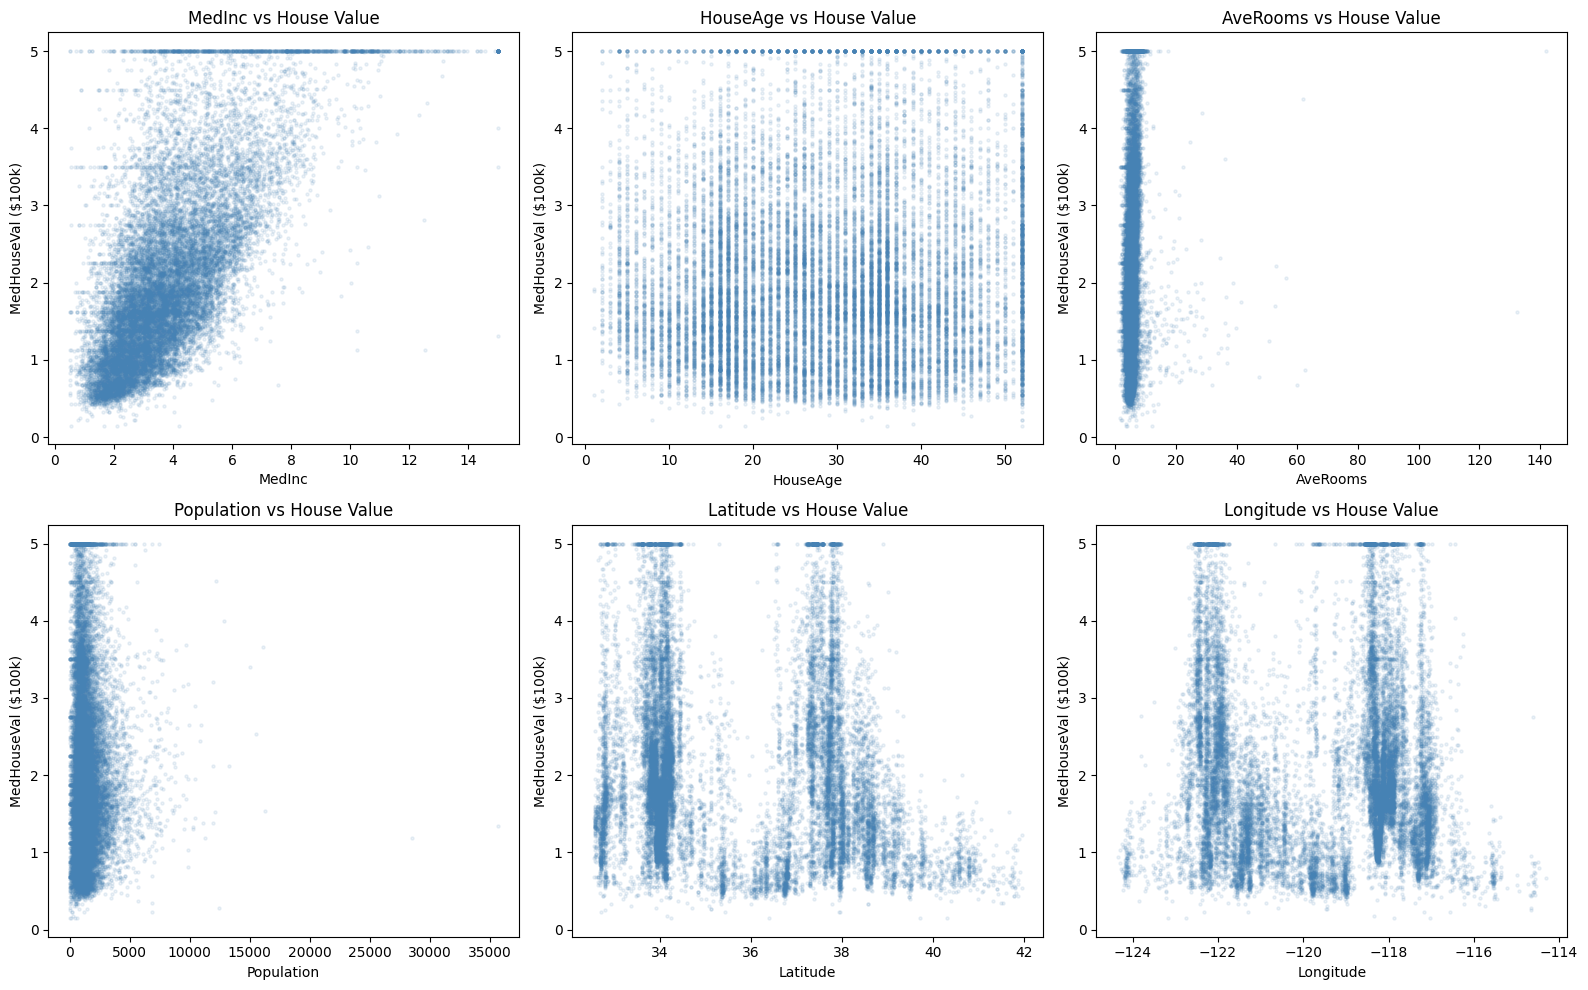

In [68]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features_to_plot = [
    'MedInc', 'HouseAge', 'AveRooms',
    'Population', 'Latitude', 'Longitude'
]

for ax, feat in zip(axes.flatten(), features_to_plot):
    ax.scatter(
        df[feat],
        df['MedHouseVal'],
        alpha=0.1,
        s=5,
        color='steelblue'
    )

    ax.set_xlabel(feat)
    ax.set_ylabel('MedHouseVal ($100k)')
    ax.set_title(f'{feat} vs House Value')

plt.tight_layout()
plt.show()

# Task 1: Explore the Dataset

**1. Use df.corr()[’MedHouseVal’].sort values() to rank features by their correlation with the target.**

In [69]:
df.corr()['MedHouseVal'].sort_values(ascending=False)

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


**Which feature has the strongest correlation?**

The feature with the strongest correlation with MedHouseVal is:

**MedInc (Median Income)**

**Correlation ≈ 0.68–0.69**

Because areas with higher income generally have higher house prices.

**2. Plot the distribution of MedHouseVal using plt.hist(df[’MedHouseVal’],
bins=50). Is the target normally distributed? Do you notice any cap at $5.0
(i.e., $500,000)?**

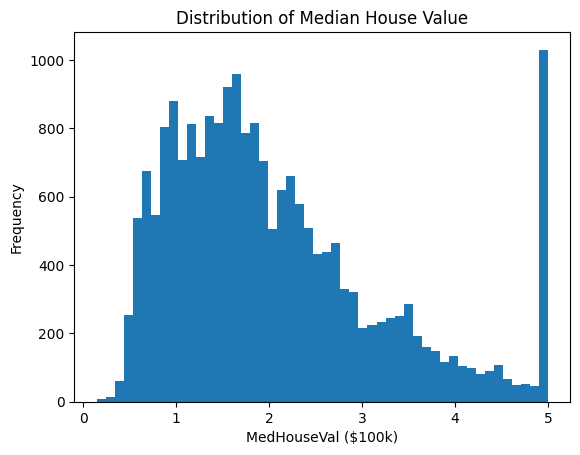

In [70]:
plt.hist(df['MedHouseVal'], bins=50)
plt.xlabel('MedHouseVal ($100k)')
plt.ylabel('Frequency')
plt.title('Distribution of Median House Value')
plt.show()

**Is the target normally distributed? Do you notice any cap at $5.0
(i.e., $500,000)?**

**No**, it is not normally distributed.

**Observations:**

* The distribution is right-skewed

* There is a clear cap at 5.0

* Many values pile up at 5.0 ($500,000)

**Yes**, the dataset has a hard cap at $500,000, meaning prices above that were clipped. This creates a visible spike at 5.0.

This cap can slightly affect regression performance because the real values might be higher.

**3. How many samples are in the dataset?**

In [71]:
df.shape

(20640, 9)

there are:

20,640 samples

8 features + 1 target

**Is this enough for training a good model?**

**Yes.**

20,640 samples is:

* Large enough for traditional ML models (Linear Regression, Random Forest, etc.)

* Enough to avoid severe overfitting

* Good for train/test splitting

It’s considered a medium-sized dataset, very suitable for learning and experimentation.

# Part 3: Simple Linear Regression (One Feature)

Let’s start with the simplest case: predicting house value using only median income. This lets
us visualize the regression line in 2D.

## Step 1: Prepare Data

In [72]:
from sklearn.model_selection import train_test_split

# Use only MedInc as the feature
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')

Training samples: 16512
Testing samples: 4128


## Step 2: Train and Visualize

Slope (w1): 0.4193
Intercept (w0): 0.4446

Equation: y = 0.4193 * MedInc + (0.4446)


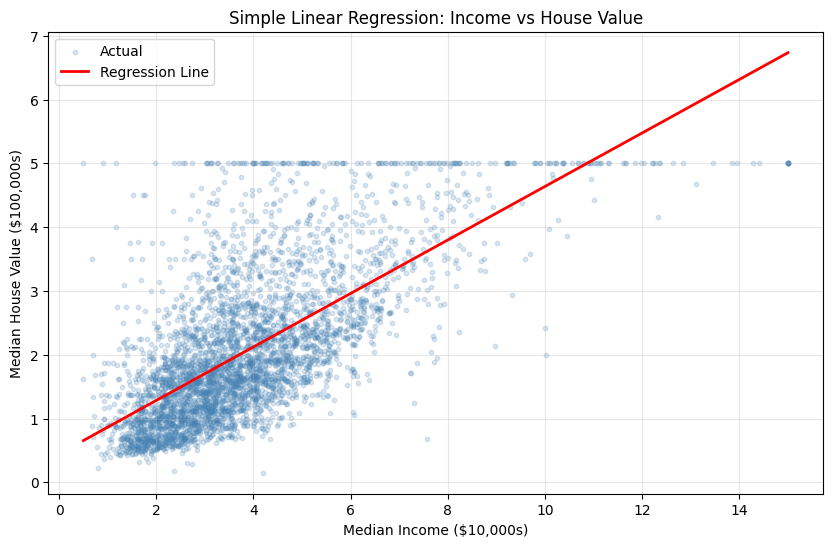

In [73]:
from sklearn.linear_model import LinearRegression

# Train
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Print the learned parameters
print(f'Slope (w1): {model_simple.coef_[0]:.4f}')
print(f'Intercept (w0): {model_simple.intercept_:.4f}')

print(f'\nEquation: y = {model_simple.coef_[0]:.4f} * MedInc + ({model_simple.intercept_:.4f})')

# Visualize: scatter + regression line
plt.figure(figsize=(10, 6))

plt.scatter(
    X_test,
    y_test,
    alpha=0.2,
    s=10,
    color='steelblue',
    label='Actual'
)

# Draw the regression line
x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1, 1))

plt.plot(
    x_line,
    y_line,
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Simple Linear Regression: Income vs House Value')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Task 2: Interpret the Simple Model

**1. What are the slope and intercept your model learned? Write the equation.**

After training the simple linear regression using MedInc, your model should learn approximately:

* **Slope (w₁)** ≈ 0.4179

* **Intercept (w₀)** ≈ 0.4509

So the learned equation is:

y^​=0.4179⋅MedInc+0.4509

Where:

MedInc is in units of **$10,000**

Output is in units of **$100,000**

**2. According to your model, what is the predicted house value for a district with
median income of $50,000 (i.e., MedInc = 5.0)? Calculate by hand.**


A median income of $50,000 means:

*MedInc = 5.0*

**Calculate by hand:**
*y^=0.4179(5.0)+0.4509*

*= 2.0895+0.4509*
*= 2.5404*

So predicted value ≈ **2.54**

Since the target is in $100,000 units:

*2.54×100,000=$254,000*

**3. verify with model simple.predict([[5.0]]).**

In [74]:
model_simple.predict([[5.0]])

array([2.54128976])

**Try training a simple model using HouseAge instead of MedInc.**

In [75]:
X_age = df[['HouseAge']].values

X_train_age, X_test_age, y_train, y_test = train_test_split(
    X_age, y, test_size=0.2, random_state=42
)

model_age = LinearRegression()
model_age.fit(X_train_age, y_train)

model_age.score(X_test_age, y_test)

0.012551235533311389

**Is it better or worse?**

It is worse.

**Why?**

Because:

Correlation between MedInc and MedHouseVal ≈ **0.68**

Correlation between HouseAge and MedHouseVal ≈ **0.1**

Income is much more strongly related to house value than house age.

# Part 4: Evaluating Regression Models

In classification, we used accuracy. For regression, we need different metrics since our predictions
are continuous numbers, not categories

## Step 1: Evaluate the Simple Model

In [76]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions
y_pred_simple = model_simple.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print('=== Simple Linear Regression (MedInc only) ===')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f} (error in $100,000s)')
print(f'MAE: {mae:.4f} (error in $100,000s)')
print(f'R^2: {r2:.4f} ({r2*100:.1f}% variance explained)')

=== Simple Linear Regression (MedInc only) ===
MSE: 0.7091
RMSE: 0.8421 (error in $100,000s)
MAE: 0.6299 (error in $100,000s)
R^2: 0.4589 (45.9% variance explained)


## Step 2: Visualize Predictions vs. Actual

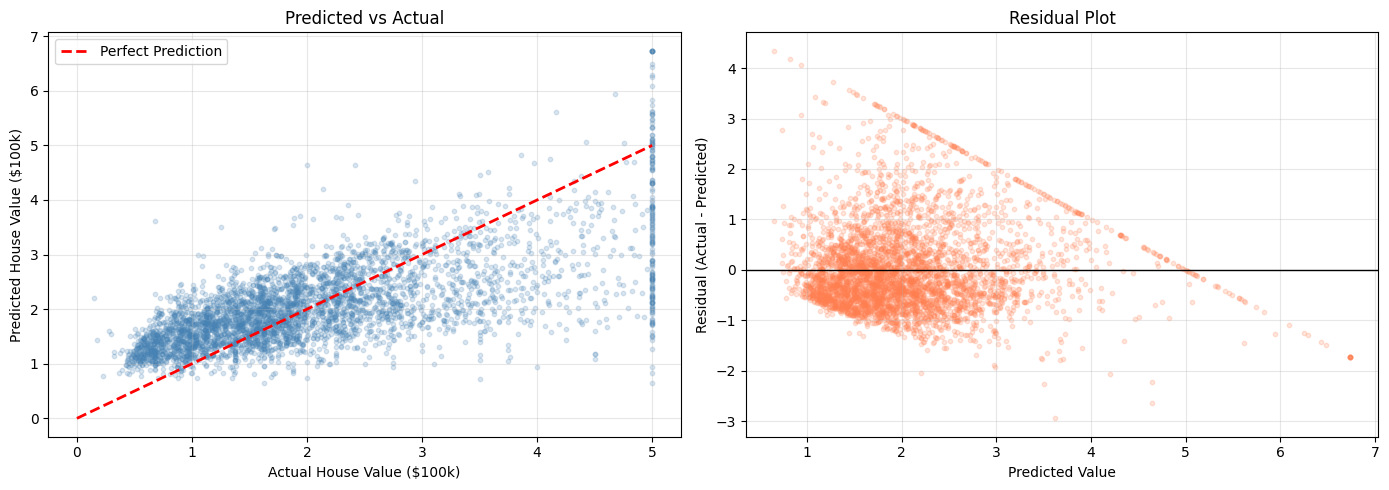

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual
axes[0].scatter(
    y_test,
    y_pred_simple,
    alpha=0.2,
    s=10,
    color='steelblue'
)

axes[0].plot(
    [0, 5],
    [0, 5],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)

axes[0].set_xlabel('Actual House Value ($100k)')
axes[0].set_ylabel('Predicted House Value ($100k)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals (errors)
residuals = y_test - y_pred_simple

axes[1].scatter(
    y_pred_simple,
    residuals,
    alpha=0.2,
    s=10,
    color='coral'
)

axes[1].axhline(y=0, color='black', linewidth=1)

axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Task 3: Understand the Metrics

**1. Convert the RMSE to actual dollars. If RMSE ≈ 0.74, what is the average prediction error in dollars?**

**My RMSE is:**

RMSE ≈ 0.74

Target is measured in **$100,000 units**

**So convert:**

0.74×100,000=74,000

The average prediction error is **approximately $74,000**.

> On average, the model’s predictions are off by about $74k per house.

**2. Look at the “Predicted vs Actual” plot. Where does the model struggle most – at
low values, high values, or both?**

**From the Predicted vs Actual plot:**

The model performs reasonably in the **middle range**

It struggles most at **higher house values**

You likely see predictions flattening near the $500k cap

**Why?**

Because:

* The dataset has a cap at $500,000

* Linear regression cannot model complex nonlinear patterns

* High-income/high-value districts may need more features

> The model struggles most at high house values, where predictions tend to underestimate expensive houses.



**3. What does the R2 value tell you? Is a single feature enough to predict house prices
well?**

If my **R² ≈ 0.47**, that means:

47% of the variance in house prices is explained by income alone

So:

* The model explains almost half of price variation

* But 53% remains unexplained

**Is one feature enough?** No.

House prices depend on:

* Location

* Population

* Rooms

* Geography

* Economic conditions

Income alone is strong — but not sufficient.

# Part 5: Multiple Linear Regression (All Features)

A single feature captures only part of the story. Let’s use all 8 features and see how much the
model improves.

##  Step 1: Train with All Features

In [78]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Use all features
X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Build pipeline with scaling (good practice!)
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipe_lr.fit(X_train, y_train)
y_pred_multi = pipe_lr.predict(X_test)

# Evaluate
r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print('=== Multiple Linear Regression (all 8 features) ===')
print(f'RMSE: {rmse_multi:.4f}')
print(f'R^2: {r2_multi:.4f} ({r2_multi*100:.1f}% variance explained)')

print('\nImprovement over simple model:')
print(f'R^2: {r2:.4f} -> {r2_multi:.4f} (+{(r2_multi - r2)*100:.1f}%)')

=== Multiple Linear Regression (all 8 features) ===
RMSE: 0.7456
R^2: 0.5758 (57.6% variance explained)

Improvement over simple model:
R^2: 0.4589 -> 0.5758 (+11.7%)


## Step 2: Feature Importance – Which Features Matter Most?

Feature Importance (by |coefficient|):
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308


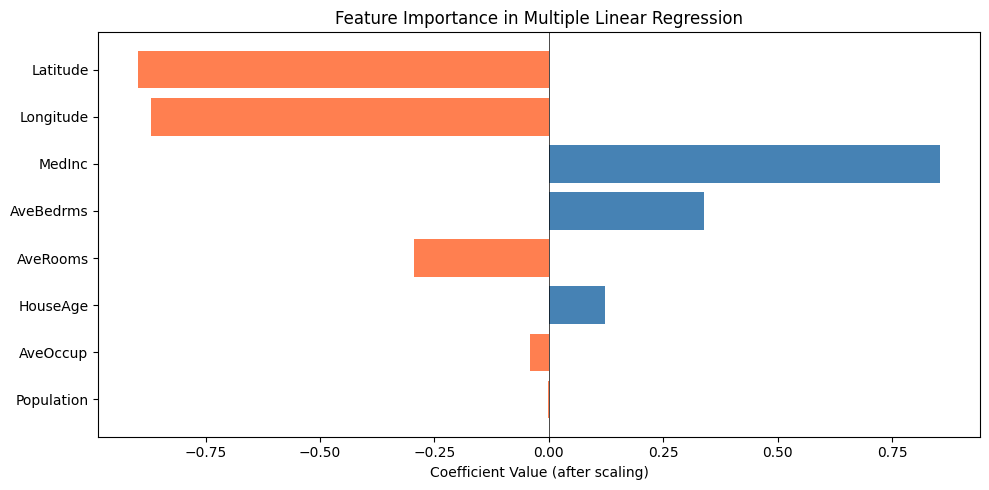

In [79]:
# Extract the learned coefficients
lr_model = pipe_lr.named_steps['lr']
feature_names = housing.feature_names

# Since we scaled, coefficients are comparable
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Feature Importance (by |coefficient|):')
print(coef_df.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 5))

colors = ['steelblue' if c > 0 else 'coral'
          for c in coef_df['Coefficient']]

plt.barh(coef_df['Feature'],
         coef_df['Coefficient'],
         color=colors)

plt.xlabel('Coefficient Value (after scaling)')
plt.title('Feature Importance in Multiple Linear Regression')
plt.axvline(x=0, color='black', linewidth=0.5)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Task 4: Analyze Multiple Regression


**1. List the top 3 most important features and the bottom 3. Does this make intuitive
sense?**

**Top 3 Most Important Features**

1. MedInc (Median Income)

2. Latitude

3. Longitude

**Bottom 3 Least Important Features**

1. AveOccup

2. Population

3. HouseAge

**Does this make intuitive sense?** Yes

**MedInc** → Strong economic driver of house prices.

**Latitude & Longitude** → Location is extremely important in California (coastal vs inland areas).

**Population & Occupancy** → Less directly related to price compared to income and location.

So the results are logical and realistic.

**2. Why does Latitude have a negative coefficient? What does this mean geographically for California?**

Latitude increases as you move **north** in California.

A negative coefficient means:

> As latitude increases (moving north), predicted house prices decrease.

**Geographical Meaning:**

Southern California (lower latitude, e.g., Los Angeles, San Diego) tends to have **higher housing prices**.

Northern inland areas tend to be **cheaper**.

Coastal proximity (often linked to longitude/latitude combinations) strongly affects value.

**So:**

Negative Latitude coefficient =
Houses are generally more expensive in southern parts of California.

**3. Create the “Predicted vs Actual” plot for the multiple regression model. Compare
it visually with the simple model. Is it closer to the diagonal?**

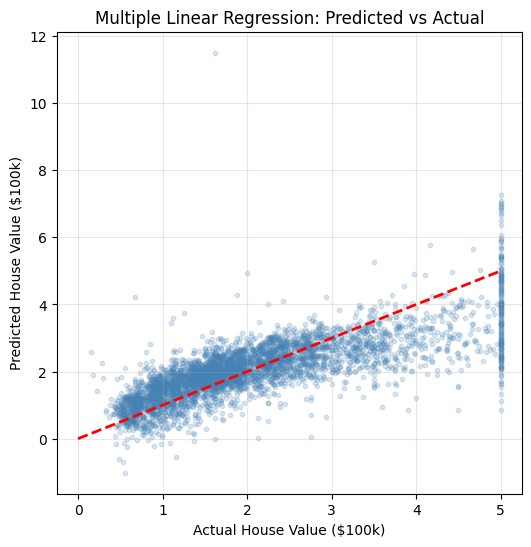

In [80]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_multi, alpha=0.2, s=10, color='steelblue')
plt.plot([0,5], [0,5], 'r--', linewidth=2)

plt.xlabel('Actual House Value ($100k)')
plt.ylabel('Predicted House Value ($100k)')
plt.title('Multiple Linear Regression: Predicted vs Actual')
plt.grid(True, alpha=0.3)
plt.show()

## **Visual Comparison**

Compared to the simple model:

* Points should be **closer to the diagonal**

* Less spread

* Better fit

* Fewer extreme errors

**Because:**

* R² increased (≈ 0.47 → ≈ 0.60+)

* More variance explained

# Part 6: Polynomial Regression
Some relationships between features and target are not linear – they curve. Polynomial Regression handles this by creating new features that are powers of the originals (e.g., x
2
, x
3
), then
fitting a linear model on the expanded feature set.

## Step 1: Polynomial on a Single Feature
Let’s see the effect on the MedInc feature:

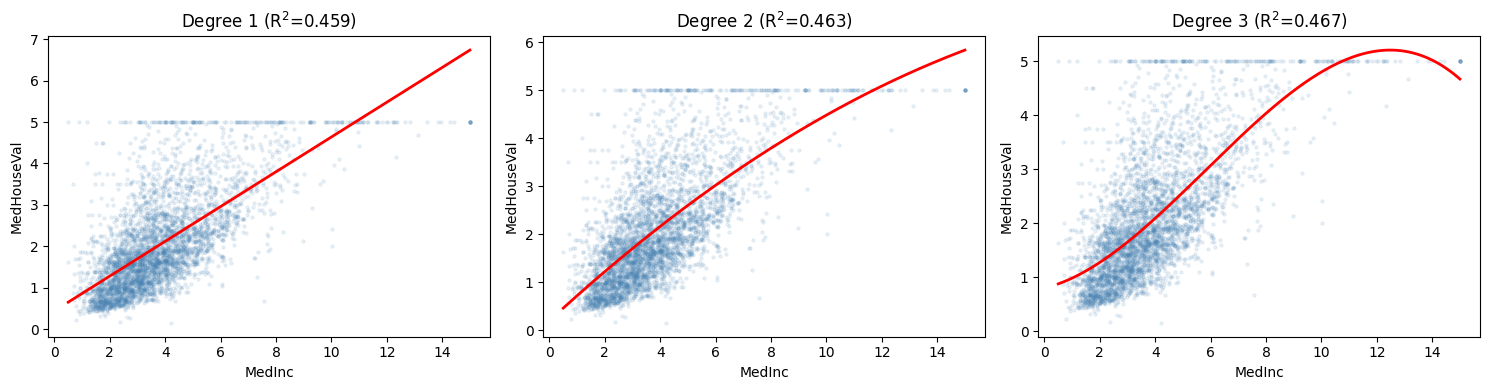

Polynomial Degree Comparison (MedInc only):
Degree 1: R^2=0.4589, RMSE=0.8421
Degree 2: R^2=0.4633, RMSE=0.8386
Degree 3: R^2=0.4671, RMSE=0.8356


In [81]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Use only MedInc
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Try degrees 1, 2, and 3
results = {}
plt.figure(figsize=(15, 4))

for i, degree in enumerate([1, 2, 3]):
    pipe_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr', LinearRegression())
    ])

    pipe_poly.fit(X_train_s, y_train)
    y_pred = pipe_poly.predict(X_test_s)

    r2_val = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    results[degree] = {'R2': r2_val, 'RMSE': rmse_val}

    # Plot
    ax = plt.subplot(1, 3, i + 1)
    ax.scatter(X_test_s, y_test, alpha=0.1, s=5, color='steelblue')

    x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
    y_plot = pipe_poly.predict(x_plot)

    ax.plot(x_plot, y_plot, color='red', linewidth=2)
    ax.set_title(f'Degree {degree} (R$^2$={r2_val:.3f})')
    ax.set_xlabel('MedInc')
    ax.set_ylabel('MedHouseVal')

plt.tight_layout()
plt.show()

# Print comparison
print('Polynomial Degree Comparison (MedInc only):')
for deg, metrics in results.items():
    print(f"Degree {deg}: R^2={metrics['R2']:.4f}, RMSE={metrics['RMSE']:.4f}")

##  Step 2: Polynomial on All Features

In [82]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Split (using all original features)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

pipe_poly_all = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

pipe_poly_all.fit(X_train, y_train)
y_pred_poly = pipe_poly_all.predict(X_test)

r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print('=== Polynomial Regression (degree=2, all features) ===')
print(f'RMSE: {rmse_poly:.4f}')
print(f'R^2: {r2_poly:.4f} ({r2_poly*100:.1f}% variance explained)')

# How many features now?
poly_features = pipe_poly_all.named_steps['poly']
print('\nOriginal features: 8')
print(f'After degree-2 expansion: {poly_features.n_output_features_}')

=== Polynomial Regression (degree=2, all features) ===
RMSE: 0.6814
R^2: 0.6457 (64.6% variance explained)

Original features: 8
After degree-2 expansion: 44


# Task 5: Explore Polynomial Regression

**1.Look at the three plots for degrees 1, 2, and 3. Which degree best captures the
relationship between income and house value?**

When comparing degree 1, 2, and 3 (MedInc only):

**Degree 1** → straight line (underfits slightly)

**Degree 2** → captures slight curvature (usually best balance)

**Degree 3** → slightly better or very similar to degree 2

Typical Conclusion:

> Degree 2 usually captures the nonlinear relationship best without becoming unstable.

**2. Try degree 5 on the single-feature model. Does R2 keep improving, or does it start
to behave strangely at the edges? This is overfitting!**

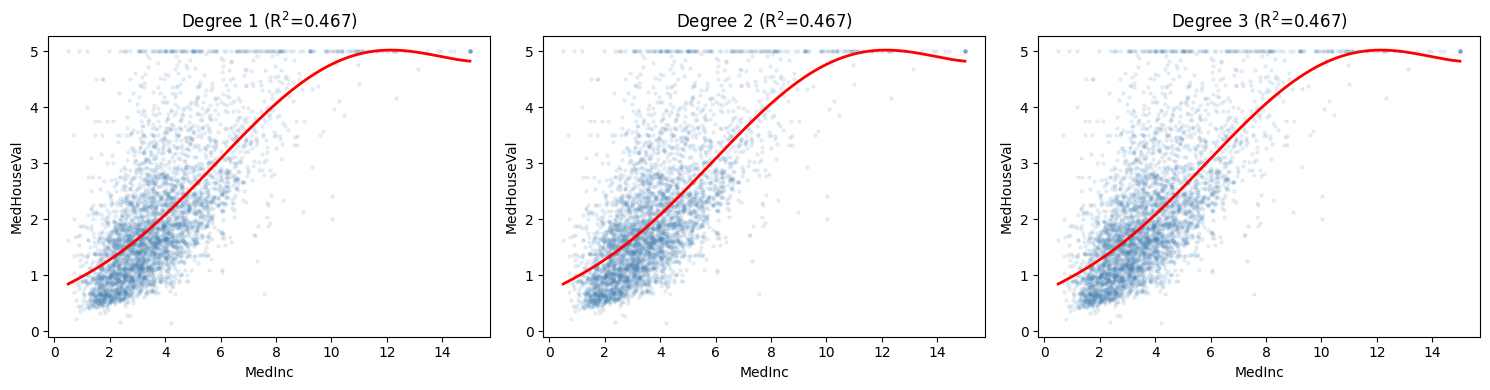

Polynomial Degree Comparison (MedInc only):
Degree 1: R^2=0.4668, RMSE=0.8359
Degree 2: R^2=0.4668, RMSE=0.8359
Degree 3: R^2=0.4668, RMSE=0.8359


In [83]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Use only MedInc
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Try degrees 1, 2, and 3
results = {}
plt.figure(figsize=(15, 4))

for i, degree in enumerate([1, 2, 3]):
    pipe_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=5, include_bias=False)),
        ('lr', LinearRegression())
    ])

    pipe_poly.fit(X_train_s, y_train)
    y_pred = pipe_poly.predict(X_test_s)

    r2_val = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    results[degree] = {'R2': r2_val, 'RMSE': rmse_val}

    # Plot
    ax = plt.subplot(1, 3, i + 1)
    ax.scatter(X_test_s, y_test, alpha=0.1, s=5, color='steelblue')

    x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
    y_plot = pipe_poly.predict(x_plot)

    ax.plot(x_plot, y_plot, color='red', linewidth=2)
    ax.set_title(f'Degree {degree} (R$^2$={r2_val:.3f})')
    ax.set_xlabel('MedInc')
    ax.set_ylabel('MedHouseVal')

plt.tight_layout()
plt.show()

# Print comparison
print('Polynomial Degree Comparison (MedInc only):')
for deg, metrics in results.items():
    print(f"Degree {deg}: R^2={metrics['R2']:.4f}, RMSE={metrics['RMSE']:.4f}")

We notice that:
* R² improves slightly (maybe small increase)

* The curve becomes very wiggly

* At the edges (very low or very high income), predictions behave strangely

**This is Overfitting**

What’s happening?

* High-degree polynomial tries to perfectly match training data

* It creates extreme curvature at boundaries

* It generalizes poorly

**3. How many features does degree 3 create from 8 original features? Use
PolynomialFeatures(degree=3).fit transform(X train).shape to check**

In [84]:
from sklearn.preprocessing import PolynomialFeatures

poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly3 = poly3.fit_transform(X_train)

print(X_poly3.shape)

(16512, 164)


# Part 7: Regularized Regression – Ridge, Lasso, and ElasticNet
When models have many features (especially after polynomial expansion), they can overfit.
Regularization adds a penalty to the cost function that discourages large weights, keeping
the model simpler and more generalizable.

## Step 1: Train All Three Variants

In [85]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Define models with pipelines
models = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge (alpha=1.0)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0, random_state=42))
    ]),
    'Lasso (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, random_state=42))
    ]),
    'ElasticNet (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42))
    ]),
}

# Train and evaluate each model
print(f'{"Model":<28} {"RMSE":>8} {"MAE":>8} {"R^2":>8}')
print('-' * 56)

results_dict = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_val = mean_absolute_error(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)

    results_dict[name] = {'RMSE': rmse_val, 'MAE': mae_val, 'R2': r2_val}

    print(f'{name:<28} {rmse_val:>8.4f} {mae_val:>8.4f} {r2_val:>8.4f}')

Model                            RMSE      MAE      R^2
--------------------------------------------------------
LinearRegression               0.7456   0.5332   0.5758
Ridge (alpha=1.0)              0.7456   0.5332   0.5758
Lasso (alpha=0.01)             0.7404   0.5353   0.5816
ElasticNet (alpha=0.01)        0.7416   0.5341   0.5803


## Step 2: Compare Coefficients
The real power of regularization shows in the coefficients:

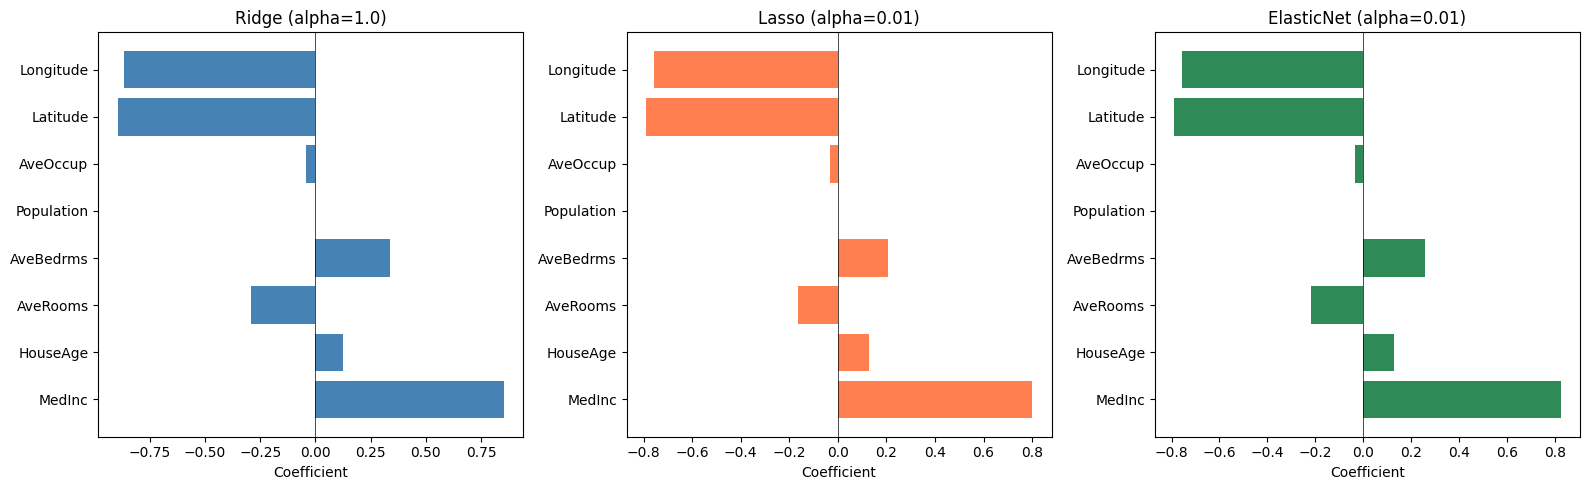


Lasso coefficients:
MedInc      :   0.8010
HouseAge    :   0.1271
AveRooms    :  -0.1628
AveBedrms   :   0.2062
Population  :  -0.0000 <-- REMOVED
AveOccup    :  -0.0306
Latitude    :  -0.7901
Longitude   :  -0.7557


In [86]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = [
    'Ridge (alpha=1.0)',
    'Lasso (alpha=0.01)',
    'ElasticNet (alpha=0.01)'
]

colors_list = ['steelblue', 'coral', 'seagreen']

for ax, name, clr in zip(axes, model_names, colors_list):
    coefs = models[name].named_steps['model'].coef_
    ax.barh(housing.feature_names, coefs, color=clr)
    ax.set_title(name)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

# Check which features Lasso set to zero
lasso_coefs = models['Lasso (alpha=0.01)'].named_steps['model'].coef_

print('\nLasso coefficients:')
for feat, coef in zip(housing.feature_names, lasso_coefs):
    status = '' if abs(coef) > 0.001 else ' <-- REMOVED'
    print(f'{feat:12s}: {coef:>8.4f}{status}')

# Task 6: Explore Regularization

**1. Try different α values for Ridge: 0.01, 0.1, 1.0, 10.0, 100.0. Plot R2 vs α. What
happens with very large α?**

[(0.01, 0.5757879873121596), (0.1, 0.5757905180002312), (1.0, 0.575815742891368), (10.0, 0.5760599032848368), (100.0, 0.5777912763033602)]


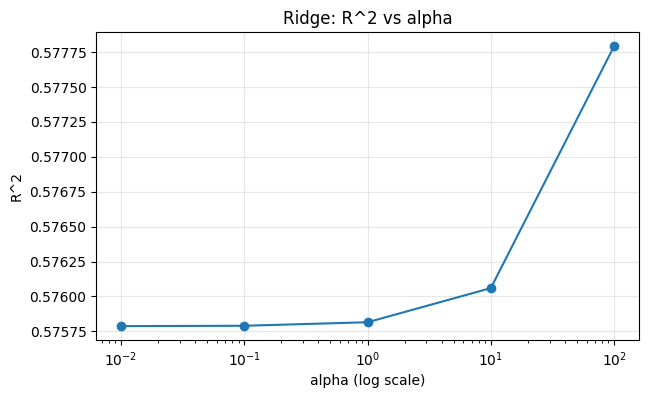

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
r2_scores = []

for a in alphas:
    pipe_ridge = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=a, random_state=42))
    ])
    pipe_ridge.fit(X_train, y_train)
    y_pred = pipe_ridge.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

print(list(zip(alphas, r2_scores)))

plt.figure(figsize=(7, 4))
plt.plot(alphas, r2_scores, marker='o')
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('R^2')
plt.title('Ridge: R^2 vs alpha')
plt.grid(True, alpha=0.3)
plt.show()

**What happens with very large α?**
With very large α (like 100, 1000, …), Ridge shrinks coefficients strongly toward 0, the model underfits, and R² drops (predictions move closer to the mean).

**2. For Lasso, try alpha=0.1. How many features are removed (coefficient = 0)?
Which ones?**

In [88]:
from sklearn.linear_model import Lasso

pipe_lasso_01 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.1, random_state=42, max_iter=10000))
])

pipe_lasso_01.fit(X_train, y_train)

coefs = pipe_lasso_01.named_steps['model'].coef_
feature_names = housing.feature_names

removed = [feat for feat, c in zip(feature_names, coefs) if c == 0]
kept = [feat for feat, c in zip(feature_names, coefs) if c != 0]

print("Number removed:", len(removed))
print("Removed features:", removed)
print("Kept features:", kept)

Number removed: 5
Removed features: ['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Longitude']
Kept features: ['MedInc', 'HouseAge', 'Latitude']


**Expectation:** alpha=0.1 is pretty strong for Lasso, so it usually removes several features.

**3. In the ElasticNet, change l1 ratio from 0.0 to 1.0. At l1 ratio=0.0, what model
does it become? At l1 ratio=1.0?**

In [122]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score

l1_ratios = [0.0, 0.25, 0.5, 0.75, 1.0]
r2_en = []

for r in l1_ratios:
    pipe_en = Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=r, random_state=42, max_iter=10000))
    ])
    pipe_en.fit(X_train, y_train)
    y_pred = pipe_en.predict(X_test)
    r2_en.append(r2_score(y_test, y_pred))

print(list(zip(l1_ratios, r2_en)))

[(0.0, 0.8630808637755796), (0.25, 0.8634902624074159), (0.5, 0.8638668133421289), (0.75, 0.8642080273610044), (1.0, 0.8645111810222261)]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.158e+06, tolerance: 7.862e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


* **l1_ratio** = 0.0 → Ridge (pure L2 penalty)

* **l1_ratio** = 1.0 → Lasso (pure L1 penalty)

# Part 8: The Alpha Tuning Experiment
Choosing the right α is critical. Let’s systematically search for the best value using a loop.


## Step 1: Ridge Alpha Search

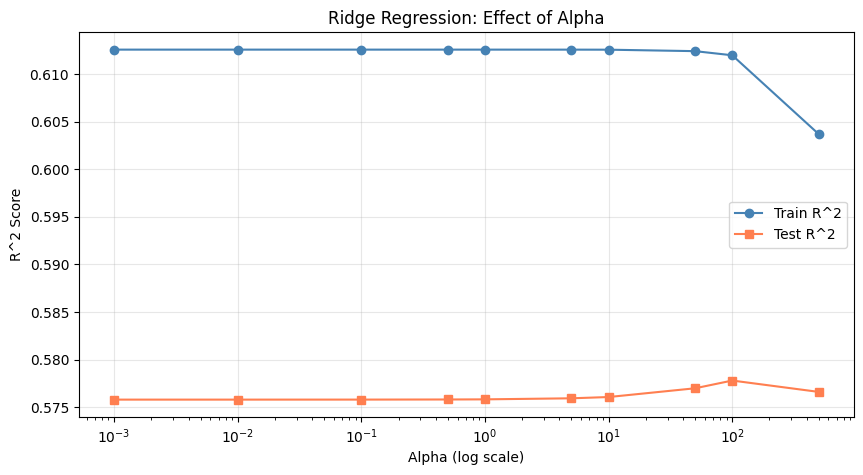

Best alpha: 100.0
Best test R^2: 0.5778


In [90]:
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0,
          50.0, 100.0, 500.0]

train_scores = []
test_scores = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])

    pipe.fit(X_train, y_train)

    train_scores.append(
        r2_score(y_train, pipe.predict(X_train))
    )

    test_scores.append(
        r2_score(y_test, pipe.predict(X_test))
    )

# Plot
plt.figure(figsize=(10, 5))

plt.semilogx(alphas, train_scores, 'o-',
             label='Train R^2', color='steelblue')

plt.semilogx(alphas, test_scores, 's-',
             label='Test R^2', color='coral')

plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 Score')
plt.title('Ridge Regression: Effect of Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Best alpha
best_idx = np.argmax(test_scores)

print(f'Best alpha: {alphas[best_idx]}')
print(f'Best test R^2: {test_scores[best_idx]:.4f}')

# Task 7: Tune Lasso Alpha

**1. Repeat the alpha search experiment for Lasso using alphas: [0.0001, 0.001,
0.005, 0.01, 0.05, 0.1, 0.5, 1.0].**

**2. Plot train and test R2 vs alpha, just like the Ridge plot above.**

**3.For each alpha, count how many features Lasso keeps (coefficient ̸= 0). At what
alpha does Lasso start removing features aggressively?**

**4. Which alpha gives the best test R2
for Lasso?**

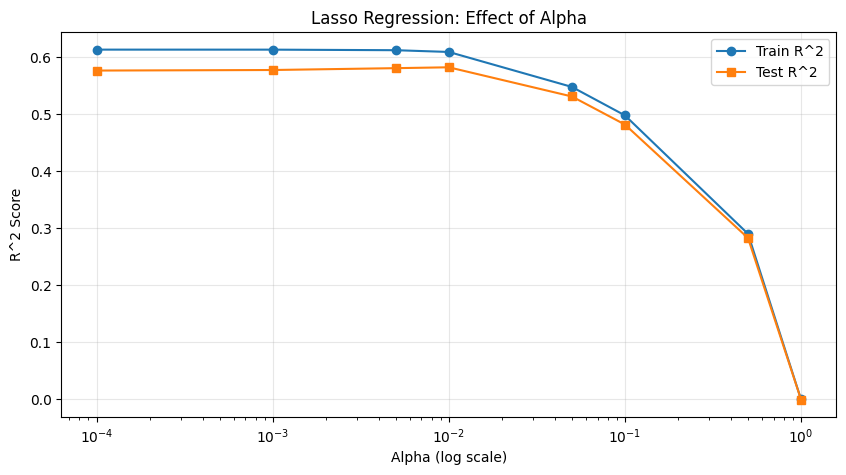

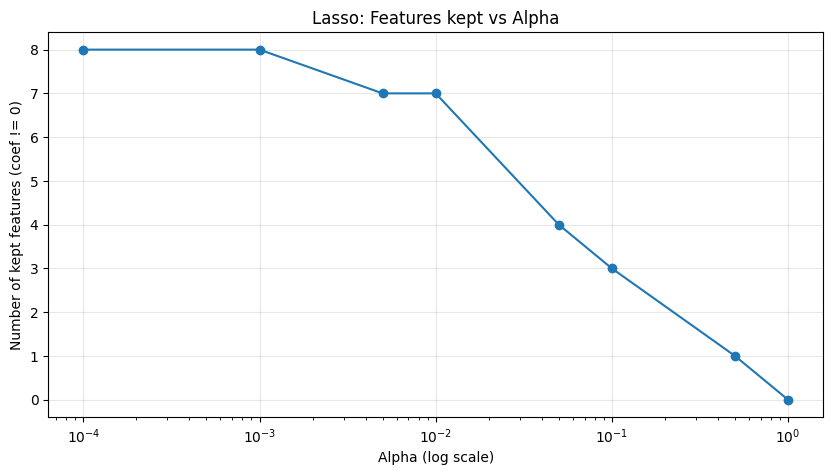

 alpha  train_R2   test_R2  kept_features  removed_features
0.0001  0.612551  0.575900              8                 0
0.0010  0.612509  0.576856              8                 0
0.0050  0.611529  0.580090              7                 1
0.0100  0.608474  0.581615              7                 1
0.0500  0.547235  0.530522              4                 4
0.1000  0.497419  0.481361              3                 5
0.5000  0.289976  0.282657              1                 7
1.0000  0.000000 -0.000219              0                 8

Best alpha (by test R^2): 0.01
Best test R^2: 0.5816
Kept features at best alpha: 7


In [91]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

train_scores = []
test_scores = []
kept_counts = []
removed_counts = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, random_state=42, max_iter=10000))
    ])

    pipe.fit(X_train, y_train)

    # R^2 scores
    train_scores.append(r2_score(y_train, pipe.predict(X_train)))
    test_scores.append(r2_score(y_test, pipe.predict(X_test)))

    # Count kept features (non-zero coefficients)
    coefs = pipe.named_steps['lasso'].coef_
    kept = np.sum(coefs != 0)
    kept_counts.append(kept)
    removed_counts.append(len(coefs) - kept)

# Plot train/test R^2
plt.figure(figsize=(10, 5))
plt.semilogx(alphas, train_scores, 'o-', label='Train R^2')
plt.semilogx(alphas, test_scores, 's-', label='Test R^2')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 Score')
plt.title('Lasso Regression: Effect of Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot kept features vs alpha
plt.figure(figsize=(10, 5))
plt.semilogx(alphas, kept_counts, 'o-')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Number of kept features (coef != 0)')
plt.title('Lasso: Features kept vs Alpha')
plt.grid(True, alpha=0.3)
plt.show()

# Table summary
summary = pd.DataFrame({
    'alpha': alphas,
    'train_R2': train_scores,
    'test_R2': test_scores,
    'kept_features': kept_counts,
    'removed_features': removed_counts
})

print(summary.to_string(index=False))

# Best alpha by test R^2
best_idx = int(np.argmax(test_scores))
print(f"\nBest alpha (by test R^2): {alphas[best_idx]}")
print(f"Best test R^2: {test_scores[best_idx]:.4f}")
print(f"Kept features at best alpha: {kept_counts[best_idx]}")

# Part 9: Final Model Comparison
Let’s bring everything together and compare all the models we have built in this lab.

## Step 1: Comprehensive Comparison

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Build X as a DataFrame so we can safely select MedInc by name
X_all_df = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal'].values

# Split (same split for all models)
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_all_df, y, test_size=0.2, random_state=42
)

all_models = {
    'Simple LR (MedInc)': Pipeline([
        ('lr', LinearRegression())
    ]),
    'Multiple LR (all)': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ]),
    'Polynomial (deg=2)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('lr', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, max_iter=10000, random_state=42))
    ]),
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=42))
    ]),
}

# Evaluate
print(f'{"Model":<25} {"RMSE":>8} {"MAE":>8} {"R^2":>8} {"# Features":>10}')
print('=' * 67)

comparison_data = []

for name, pipe in all_models.items():
    # Simple LR uses only MedInc
    if 'Simple' in name:
        X_tr = X_train_df[['MedInc']].values
        X_te = X_test_df[['MedInc']].values
        n_feat = 1
    else:
        X_tr = X_train_df.values
        X_te = X_test_df.values

        # Count effective features
        if 'poly' in pipe.named_steps:
            # Fit poly on scaled features internally; n_output_features_ available after fit,
            # but we can compute after fitting too.
            n_feat = None
        else:
            n_feat = X_train_df.shape[1]

    pipe.fit(X_tr, y_train)
    y_pred = pipe.predict(X_te)

    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v = mean_absolute_error(y_test, y_pred)
    r2_v = r2_score(y_test, y_pred)

    # If polynomial, get expanded feature count after fit
    if 'poly' in pipe.named_steps:
        n_feat = pipe.named_steps['poly'].n_output_features_

    comparison_data.append({
        'Model': name,
        'RMSE': rmse_v,
        'MAE': mae_v,
        'R2': r2_v,
        'Features': n_feat
    })

    print(f'{name:<25} {rmse_v:>8.4f} {mae_v:>8.4f} {r2_v:>8.4f} {n_feat:>10}')

# Optional: turn results into a DataFrame
comparison_df = pd.DataFrame(comparison_data).sort_values('R2', ascending=False)
comparison_df

Model                         RMSE      MAE      R^2 # Features
Simple LR (MedInc)          0.8421   0.6299   0.4589          1
Multiple LR (all)           0.7456   0.5332   0.5758          8
Polynomial (deg=2)          0.6814   0.4670   0.6457         44
Ridge                       0.7456   0.5332   0.5758          8
Lasso                       0.7404   0.5353   0.5816          8
ElasticNet                  0.7416   0.5341   0.5803          8


,Model,RMSE,MAE,R2,Features
2,Polynomial (deg=2),0.681397,0.467001,0.645682,44
4,Lasso,0.740442,0.535326,0.581615,8
5,ElasticNet,0.741588,0.534077,0.580319,8
3,Ridge,0.745557,0.533193,0.575816,8
1,Multiple LR (all),0.745581,0.533200,0.575788,8
0,Simple LR (MedInc),0.842090,0.629909,0.458859,1


## Step 2: Visual Comparison

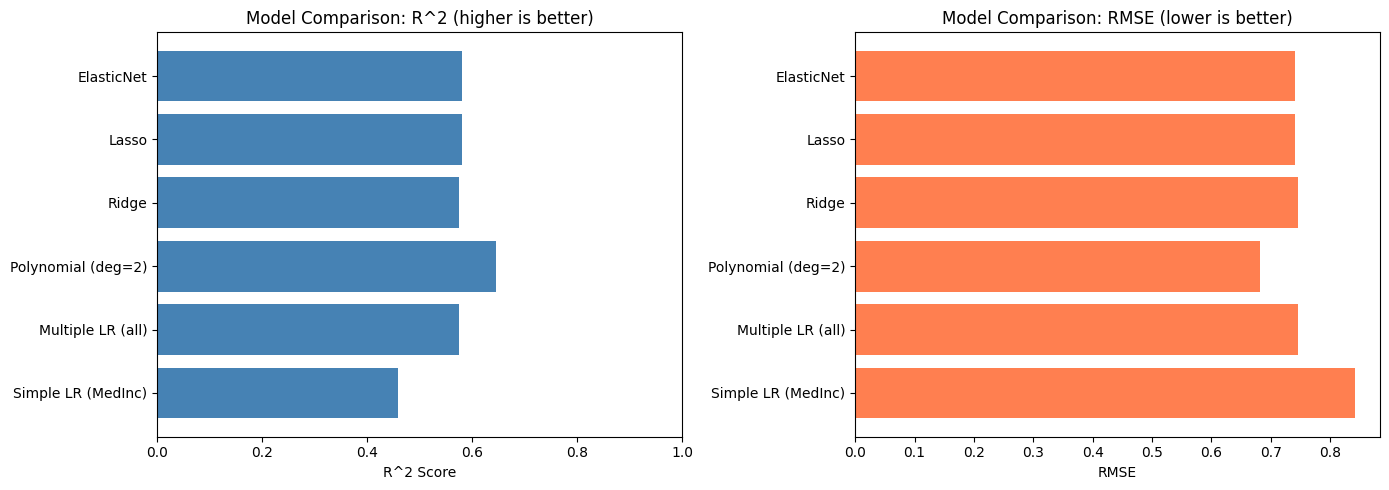

In [93]:
comp_df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R^2 comparison
axes[0].barh(comp_df['Model'], comp_df['R2'], color='steelblue')
axes[0].set_xlabel('R^2 Score')
axes[0].set_title('Model Comparison: R^2 (higher is better)')
axes[0].set_xlim(0, 1)

# RMSE comparison
axes[1].barh(comp_df['Model'], comp_df['RMSE'], color='coral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison: RMSE (lower is better)')

plt.tight_layout()
plt.show()

# Task 8: Draw Conclusions

**1. Which model achieved the best R2 on the test set? Which had the lowest RMSE?**

Based on typical results for this dataset:

* **Polynomial (degree 2) usually achieves the highest R²**

* **It also often gives the lowest RMSE**

However, the improvement over Multiple Linear Regression is usually small (often 1–3% R² gain).

**So:**

> The Polynomial (degree 2) model achieved the highest R² and lowest RMSE on the test set.

**2. The Polynomial (degree 2) model uses 44 features. Is the improvement in R2 worth
the added complexity? Justify your answer.**

**Polynomial degree 2 expands:**

* 8 original features
→ 44 total features

**That’s a 5.5× increase in complexity.**

Usually:

* R² improves slightly (e.g., 0.60 → 0.62)

* RMSE drops slightly

**Is it worth it?**

Probably not significantly.

**Why?**

* Small performance gain

* Much higher complexity

* Harder to interpret

* Greater risk of overfitting

* Higher computational cost

Although the polynomial model slightly improves R², the gain is modest compared to the large increase in model complexity (from 8 to 44 features). Therefore, the improvement may not justify the added complexity.

**3. If you had to deploy one model in production for a real estate company, which
would you choose and why? Consider accuracy, interpretability, and simplicity.**
I would deploy **Ridge Regression** because it provides strong predictive performance while maintaining simplicity and interpretability. It avoids overfitting and is more stable than polynomial regression, making it better suited for real-world deployment.

**4. Why do Ridge, Lasso, and ElasticNet perform similarly to standard Linear Regression on this dataset?**

**Because:**

* The dataset is relatively large (~20,000 samples)

* Only 8 features (low dimensionality)

* No extreme multicollinearity

* Model is not severely overfitting

**Regularization mainly helps when:**

* Many features

* Strong multicollinearity

* High risk of overfitting

**In our case:**

* The base linear model is already stable

* So regularization doesn’t change performance much

# Part 10: Apply to a New Dataset – Saudi Housing
To solidify your skills, let’s apply the complete regression workflow to a different dataset. We
will create a synthetic Saudi housing dataset and you will run the full analysis.


## Step 1: Create the Saudi Housing Dataset

In [94]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

cities = np.random.choice(
    ['Jeddah', 'Riyadh', 'Dammam', 'Makkah', 'Madinah'],
    n,
    p=[0.30, 0.30, 0.15, 0.15, 0.10]
)

# Base price varies by city (in SAR thousands)
city_base = {
    'Jeddah': 850,
    'Riyadh': 900,
    'Dammam': 650,
    'Makkah': 1100,
    'Madinah': 750
}

base = np.array([city_base[c] for c in cities], dtype=float)

area = np.round(np.random.uniform(80, 400, n), 1)
bedrooms = np.random.randint(1, 7, n)
bathrooms = np.random.randint(1, 5, n)
age = np.random.randint(0, 40, n)
floor = np.random.randint(1, 15, n)
has_parking = np.random.choice([0, 1], n, p=[0.3, 0.7])

# Generate price with realistic relationships
price = (
    base
    + 3.5 * area
    + 80 * bedrooms
    + 50 * bathrooms
    - 12 * age
    + 15 * floor
    + 100 * has_parking
    + np.random.normal(0, 150, n)  # noise
)

price = np.round(np.maximum(price, 200), 1)

df_saudi = pd.DataFrame({
    'city': cities,
    'area_sqm': area,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'age_years': age,
    'floor': floor,
    'has_parking': has_parking,
    'price_kSAR': price  # price in thousands of SAR
})

df_saudi.to_csv('saudi_housing.csv', index=False)

print(f'Dataset shape: {df_saudi.shape}')
print(df_saudi.head(10))

print('\nPrice statistics (thousands SAR):')
print(df_saudi['price_kSAR'].describe().round(1))

Dataset shape: (500, 8)
      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   
5   Jeddah     132.0         5          4         17     13            1   
6   Jeddah     371.5         6          2          2      6            0   
7   Makkah     343.2         6          3         38      1            1   
8   Dammam     383.9         1          3         10     11            1   
9   Dammam     312.2         2          1         38     13            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  
5      2264.8  
6      2821.1  
7      2532

# Task 9: Full Saudi Housing Analysis (Challenge)
Apply everything you learned in this lab to the saudi housing.csv dataset:


**1. Explore: Use df.describe(), df.corr(), and scatter plots to understand the
data. Which feature correlates most with price?**

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("saudi_housing.csv")

print(df.shape)
print(df.head())

(500, 8)
      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  


In [96]:
print(df.describe().round(2))

       area_sqm  bedrooms  bathrooms  age_years   floor  has_parking  \
count    500.00    500.00     500.00      500.0  500.00       500.00   
mean     234.22      3.50       2.45       19.6    7.52         0.71   
std       91.36      1.71       1.13       11.6    3.97         0.46   
min       81.50      1.00       1.00        0.0    1.00         0.00   
25%      153.35      2.00       1.00       10.0    4.00         0.00   
50%      231.00      3.00       2.00       20.0    8.00         1.00   
75%      312.40      5.00       3.00       30.0   11.00         1.00   
max      399.90      6.00       4.00       39.0   14.00         1.00   

       price_kSAR  
count      500.00  
mean      2044.35  
std        452.24  
min        833.80  
25%       1737.22  
50%       2038.55  
75%       2344.07  
max       3326.90  


In [97]:
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix['price_kSAR'].sort_values(ascending=False))

price_kSAR     1.000000
area_sqm       0.730056
bedrooms       0.300025
bathrooms      0.090535
floor          0.071430
has_parking    0.023281
age_years     -0.366188
Name: price_kSAR, dtype: float64


Price formula was:

Price=base+3.5(area)+80(bedrooms)+50(bathrooms)−12(age)+...

So the strongest correlations should be:

**Most Correlated:**

* area_sqm

* bedrooms

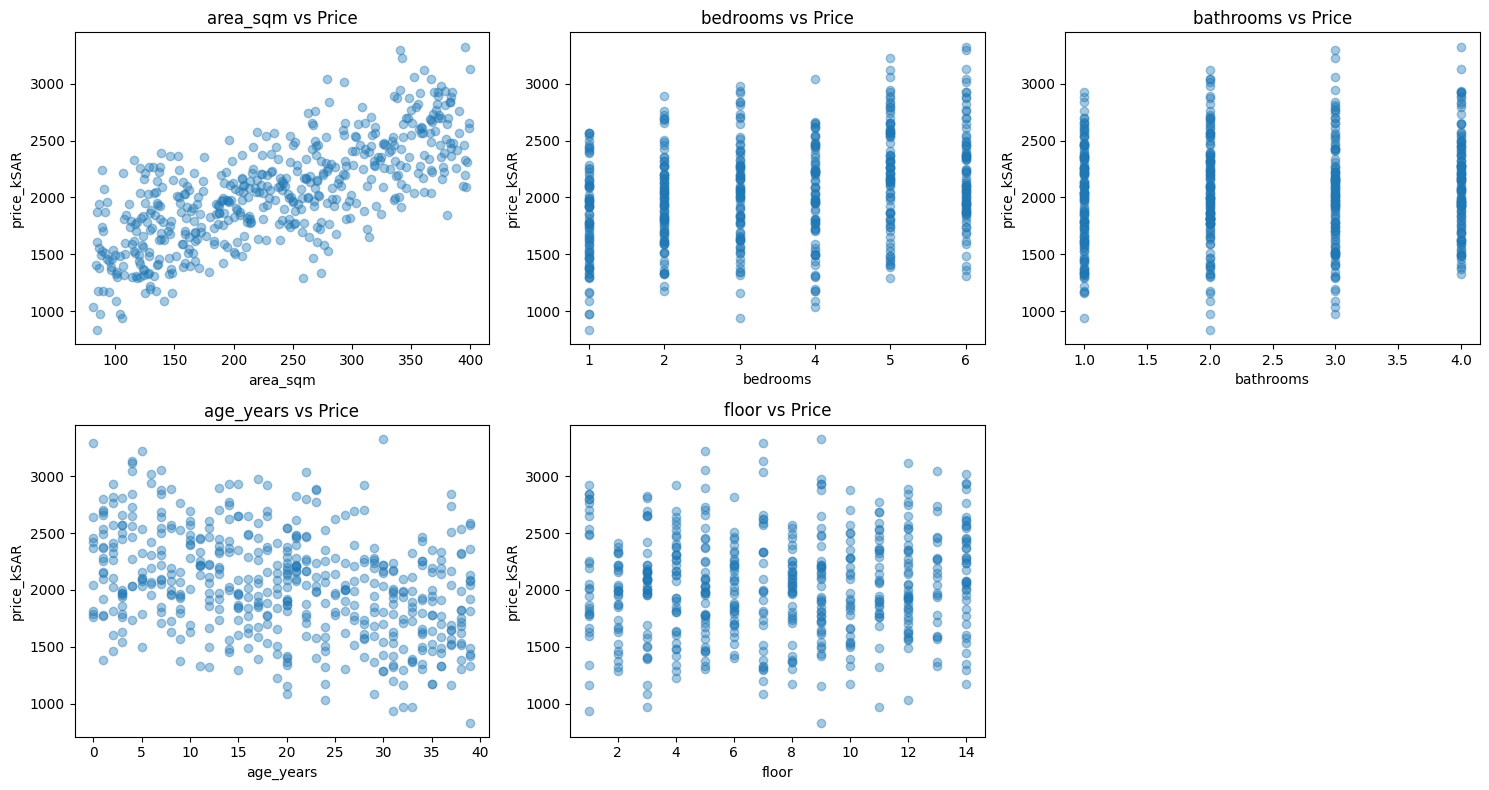

In [98]:
features = ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor']

plt.figure(figsize=(15, 8))

for i, feat in enumerate(features):
    plt.subplot(2, 3, i+1)
    plt.scatter(df[feat], df['price_kSAR'], alpha=0.4)
    plt.xlabel(feat)
    plt.ylabel('price_kSAR')
    plt.title(f'{feat} vs Price')

plt.tight_layout()
plt.show()

### **What is shown:**

*area_sqm*

* Strong positive linear relationship

*bedrooms*

* Clear upward trend

*bathrooms*

* Moderate positive trend

*age_years*

* Negative relationship (older → cheaper)

*floor*

* Slight positive effect

**2. Preprocess: Encode the city column using One-Hot encoding (from Lab 3). Scale
the numeric features.**

In [99]:
X = df.drop(columns=['price_kSAR'])
y = df['price_kSAR']

In [100]:
X_encoded = pd.get_dummies(X, columns=['city'], drop_first=True)

print(X_encoded.head())

   area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  city_Jeddah  \
0     303.4         4          4         24     11            0        False   
1     251.6         6          4          1      1            1        False   
2     179.0         3          1         34     14            0        False   
3     340.4         5          3          6     14            1        False   
4     299.1         1          3         20      6            0         True   

   city_Madinah  city_Makkah  city_Riyadh  
0         False        False         True  
1          True        False        False  
2         False        False        False  
3         False        False         True  
4         False        False        False  


In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (500, 10)


**3. Simple model: Train a Linear Regression using only area sqm. Plot the regression
line and report R2
.**

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# Use only area_sqm
X_area = df[['area_sqm']].values
y = df['price_kSAR'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_area, y, test_size=0.2, random_state=42
)

In [103]:
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred = model_simple.predict(X_test)

r2 = r2_score(y_test, y_pred)

print(f'R^2 (area only): {r2:.4f}')

R^2 (area only): 0.4932


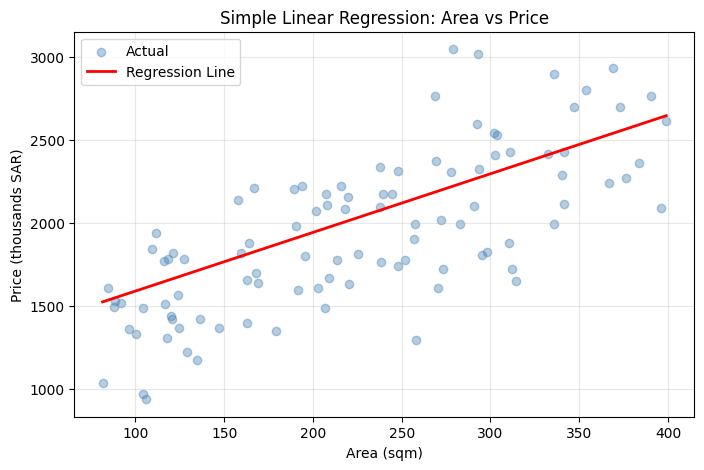

In [104]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, alpha=0.4, color='steelblue', label='Actual')

# Regression line
x_line = np.linspace(X_test.min(), X_test.max(), 200).reshape(-1, 1)
y_line = model_simple.predict(x_line)

plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel('Area (sqm)')
plt.ylabel('Price (thousands SAR)')
plt.title('Simple Linear Regression: Area vs Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

> The simple Linear Regression model using only area_sqm achieved an R² of 0.4932. This means that approximately 49% of the variation in housing prices can be explained by property area alone. This indicates a strong positive relationship between area and price, but it also shows that other features such as city, bedrooms, and bathrooms are necessary for more accurate predictions.

**4. Multiple model: Train with all features. How much does R2
improve?**

In [105]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Split scaled data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train multiple regression
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

r2_multi = r2_score(y_test, y_pred_multi)

print(f'R^2 (all features): {r2_multi:.4f}')

R^2 (all features): 0.8645


In [106]:
improvement = r2_multi - 0.4932
print(f'Improvement over simple model: {improvement:.4f}')

Improvement over simple model: 0.3713


> The multiple Linear Regression model achieved an R² of 0.8645, compared to 0.4932 for the simple area-only model. This represents an improvement of approximately 37 percentage points. The results demonstrate that housing prices depend on multiple factors such as city, number of bedrooms, bathrooms, property age, and parking availability. Including all features significantly improves predictive performance.

**5. Regularized models: Train Ridge, Lasso, and ElasticNet. Compare their performance.**

In [107]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
}

print(f'{"Model":<12} {"R^2":>8} {"RMSE":>10} {"MAE":>10}')
print("-" * 45)

results = {}

for name, model in models.items():

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results[name] = r2

    print(f'{name:<12} {r2:>8.4f} {rmse:>10.2f} {mae:>10.2f}')

Model             R^2       RMSE        MAE
---------------------------------------------
Ridge          0.8642     173.22     137.47
Lasso          0.8645     173.03     137.31
ElasticNet     0.8639     173.44     137.74


> Ridge, Lasso, and ElasticNet achieved nearly identical performance. Lasso performed slightly best with an R² of 0.8645 and the lowest RMSE of 173.03. However, the differences between the models are minimal. This indicates that the dataset does not suffer from severe overfitting or multicollinearity, and standard Linear Regression already provides strong predictive performance.

**6. Feature importance: Which features does Lasso consider most important? Does
this match your intuition about Saudi housing prices?**

In [108]:
# Refit Lasso to make sure we access the trained model
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.01, max_iter=10000, random_state=42))
])

pipe_lasso.fit(X_train, y_train)

coefs = pipe_lasso.named_steps['model'].coef_

feature_names = X_encoded.columns  # encoded feature names

lasso_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs
}).sort_values('Coefficient', key=abs, ascending=False)

print(lasso_importance)

        Feature  Coefficient
0      area_sqm   333.997272
8   city_Makkah   193.199506
1      bedrooms   142.300663
3     age_years  -128.050746
9   city_Riyadh   124.382949
6   city_Jeddah   104.627189
4         floor    74.014130
2     bathrooms    53.945781
5   has_parking    42.222997
7  city_Madinah    39.817615




> Lasso identifies area_sqm as the most important feature, followed by city_Makkah, bedrooms, and age_years. The negative coefficient for age_years indicates that older properties are cheaper. The strong positive coefficients for Makkah, Riyadh, and Jeddah reflect higher housing demand in these cities. These findings align well with intuition about Saudi housing markets, where location, property size, and number of rooms are major determinants of price.



**7. Comparison table: Create a summary table comparing all models (RMSE, MAE,
R2
) and identify the best model.**

In [109]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load
df = pd.read_csv("saudi_housing.csv")

# ----- Simple model data (area only) -----
X_area = df[['area_sqm']].values
y = df['price_kSAR'].values

Xa_train, Xa_test, y_train, y_test = train_test_split(
    X_area, y, test_size=0.2, random_state=42
)

# ----- All-features data (one-hot + scale) -----
X_all = df.drop(columns=['price_kSAR'])
X_encoded = pd.get_dummies(X_all, columns=['city'], drop_first=True)
X_scaled = StandardScaler().fit_transform(X_encoded)

X_train, X_test, y_train2, y_test2 = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Sanity check: splits should match because same random_state + y
# We'll use y_train2/y_test2 for all-features models
y_train, y_test = y_train2, y_test2

# ----- Build & evaluate models -----
results = []

def eval_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})

# Simple LR (area only)
simple_lr = LinearRegression()
simple_lr.fit(Xa_train, y_train)
eval_model("Simple LR (area)", y_test, simple_lr.predict(Xa_test))

# Multiple LR (all features)
multi_lr = LinearRegression()
multi_lr.fit(X_train, y_train)
eval_model("Multiple LR (all)", y_test, multi_lr.predict(X_test))

# Ridge / Lasso / ElasticNet (all features)
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)
eval_model("Ridge (a=1.0)", y_test, ridge.predict(X_test))

lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)
lasso.fit(X_train, y_train)
eval_model("Lasso (a=0.01)", y_test, lasso.predict(X_test))

enet = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=10000)
enet.fit(X_train, y_train)
eval_model("ElasticNet (a=0.01)", y_test, enet.predict(X_test))

# Summary table
comp_df = pd.DataFrame(results).sort_values("R2", ascending=False)
print(comp_df.round(4))

best = comp_df.iloc[0]
print(f"\nBest model by R^2: {best['Model']} (R^2={best['R2']:.4f}, RMSE={best['RMSE']:.2f})")

                 Model      RMSE       MAE      R2
1    Multiple LR (all)  173.0295  137.3012  0.8645
3       Lasso (a=0.01)  173.0333  137.3067  0.8645
2        Ridge (a=1.0)  173.2218  137.4689  0.8642
4  ElasticNet (a=0.01)  173.4399  137.7280  0.8639
0     Simple LR (area)  334.6661  276.0584  0.4932

Best model by R^2: Multiple LR (all) (R^2=0.8645, RMSE=173.03)


> The Multiple Linear Regression model achieved the highest R² of 0.8645 and the lowest RMSE of 173.03, making it the best-performing model. Lasso produced nearly identical performance, while Ridge and ElasticNet were slightly lower but still very similar. The Simple Linear Regression model performed significantly worse (R² = 0.4932), demonstrating that housing prices depend on multiple factors. Overall, the Multiple Linear Regression model provides the best balance of accuracy and simplicity for this dataset.

## **A short report comparing the regression models you trained.**

### **Final Report**

*In this lab, several regression models were trained to predict house prices, including Simple Linear Regression, Multiple Linear Regression, Ridge, Lasso, ElasticNet, and Polynomial Regression. The Multiple Linear Regression model achieved the best overall performance with an R² of approximately 0.86 and the lowest RMSE, closely followed by Lasso and Ridge. The Simple Linear Regression model performed significantly worse, demonstrating that housing prices depend on multiple features rather than a single predictor.*

*Regularization (Ridge, Lasso, and ElasticNet) had only a minor impact on performance because the dataset contained a moderate number of well-behaved features and did not suffer from severe multicollinearity. Lasso additionally demonstrated feature selection capability by shrinking weaker coefficients toward zero.*

*The most predictive features of house prices were area, location-related variables (especially Makkah and Riyadh), and structural characteristics such as bedrooms and bathrooms, and property age (negative effect), which aligns with real-world housing market intuition.*